# External AMP Classifier Baseline + Condition Adherence for cVAE

This notebook builds a **sequence-only external multi-label classifier** and then uses it as a **proxy evaluator** for cVAE generations.

**Why this notebook exists**
- train a baseline classifier on the AMP labels used by the generator
- measure standard multi-label classification metrics on held-out data
- tune per-label thresholds for more realistic downstream screening
- score generated peptides for condition adherence and off-target activity

**Targets**
- `is_antibacterial`
- `is_anti_gram_positive`
- `is_anti_gram_negative`
- `is_antifungal`
- `is_anticancer`
- optional harder labels: `is_antiviral`, `is_antiparasitic`

**Notebook roadmap**
1. Load and inspect the peptide dataset.
2. Train a BiLSTM classifier baseline.
3. Evaluate test-set performance and tune thresholds.
4. Load the cVAE and score generated peptides.
5. Summarize what the baseline supports, where it fails, and what to improve next.


In [1]:
# Core imports
import os
import math
import json
import random
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    balanced_accuracy_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

device: cpu


In [2]:
# Project paths
ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(os.getcwd()).parent
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

DATA_PATH = DATA_DIR / "preprocessed" / "data.csv"
VOCAB_PATH = MODELS_DIR / "vocab.pkl"

print("ROOT:", ROOT)
print("DATA_PATH:", DATA_PATH)
print("MODELS_DIR:", MODELS_DIR)
print("VOCAB_PATH:", VOCAB_PATH)

ROOT: C:\Users\artem\Study\AMPs-via-VAE\model_training
DATA_PATH: C:\Users\artem\Study\AMPs-via-VAE\model_training\data\preprocessed\data.csv
MODELS_DIR: C:\Users\artem\Study\AMPs-via-VAE\model_training\models
VOCAB_PATH: C:\Users\artem\Study\AMPs-via-VAE\model_training\models\vocab.pkl


## 1. Load data
The notebook expects the same preprocessed APD-style CSV as the generator notebook.

This section checks that the label columns are present and gives a quick view of sequence length statistics before any modeling starts.


In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"{DATA_PATH} not found. Run preprocessing first.")

df = pd.read_csv(DATA_PATH)

seq_col = "Sequence"
len_col = "Length"

target_cols = [
    "is_antibacterial",
    "is_anti_gram_positive",
    "is_anti_gram_negative",
    "is_antifungal",
    "is_anticancer",
    "is_antiviral",       # bonus
    "is_antiparasitic",   # bonus
]

required_cols = [seq_col] + target_cols
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in dataset: {missing}")

df = df[required_cols + ([len_col] if len_col in df.columns else [])].dropna(subset=[seq_col]).copy()
df[seq_col] = df[seq_col].astype(str).str.strip().str.upper()

for c in target_cols:
    df[c] = df[c].fillna(0).astype(int)

if len_col not in df.columns:
    df[len_col] = df[seq_col].str.len()

df = df[(df[seq_col].str.len() > 0)].reset_index(drop=True)

print("Dataset size:", df.shape)
display(df.head())

print("\nLabel prevalence:")
for c in target_cols:
    print(f"{c:24s} {df[c].sum():5d} / {len(df):5d} = {df[c].mean():.3f}")

Dataset size: (5984, 9)


,Sequence,is_antibacterial,is_anti_gram_positive,is_anti_gram_negative,is_antifungal,is_anticancer,is_antiviral,is_antiparasitic,Length
0,GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV,1,1,1,1,1,0,1,33
1,YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY,1,1,1,0,0,0,0,34
2,DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSV...,0,0,0,1,0,0,0,54
3,NLCERASLTWTGNCGNTGHCDTQCRNWESAKHGACHKRGNWKCFCYFDC,1,1,0,1,0,0,0,49
4,VFIDILDKVENAIHNAAQVGIGFAKPFEKLINPK,1,1,0,0,0,0,0,34



Label prevalence:
is_antibacterial          5136 /  5984 = 0.858
is_anti_gram_positive     4097 /  5984 = 0.685
is_anti_gram_negative     4393 /  5984 = 0.734
is_antifungal             1755 /  5984 = 0.293
is_anticancer              321 /  5984 = 0.054
is_antiviral               241 /  5984 = 0.040
is_antiparasitic           331 /  5984 = 0.055


In [5]:
# Basic sequence length summary
display(df[len_col].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("length"))

,length
count,5984.000000
mean,24.029412
std,11.195353
min,5.000000
10%,12.000000
25%,14.000000
50%,22.000000
75%,31.000000
90%,40.000000
95%,46.000000


## 2. Build vocabulary
We keep this classifier self-contained and independent from the VAE vocabulary, but we also optionally reuse `vocab.pkl` when available to stay aligned with the generator.

In [6]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"

if VOCAB_PATH.exists():
    with open(VOCAB_PATH, "rb") as f:
        vocab_obj = pickle.load(f)
    char2idx = vocab_obj["char2idx"]
    idx2char = vocab_obj["idx2char"]
    max_len = int(vocab_obj["max_len"])
    print("Loaded tokenizer from vocab.pkl")
else:
    alphabet = sorted({aa for seq in df[seq_col] for aa in seq})
    vocab_list = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN] + alphabet
    char2idx = {ch: i for i, ch in enumerate(vocab_list)}
    idx2char = {i: ch for ch, i in char2idx.items()}
    max_len = int(min(max(df[len_col].max() + 2, 16), 64))
    print("Built tokenizer from data")

PAD_IDX = char2idx[PAD_TOKEN]
UNK_IDX = char2idx[UNK_TOKEN]
SOS_IDX = char2idx[SOS_TOKEN]
EOS_IDX = char2idx[EOS_TOKEN]
vocab_size = len(char2idx)

print("vocab_size:", vocab_size)
print("max_len:", max_len)

Built tokenizer from data
vocab_size: 24
max_len: 64


In [7]:
def tokenize(seq, max_len=max_len):
    tokens = [SOS_IDX] + [char2idx.get(ch, UNK_IDX) for ch in seq] + [EOS_IDX]
    seq_len = min(len(tokens), max_len)
    tokens = tokens[:max_len]
    if len(tokens) < max_len:
        tokens = tokens + [PAD_IDX] * (max_len - len(tokens))
    return tokens, seq_len

## 3. Train/val/test split
We use a deterministic random split for a fast baseline.

This is sufficient for a first screening model, but it is not a publishable evaluation protocol because homologous peptides can leak across splits. For a stronger study, replace this with a **homology-aware split**.


In [8]:
idx = np.arange(len(df))
rng = np.random.default_rng(SEED)
rng.shuffle(idx)

n = len(idx)
n_train = int(0.8 * n)
n_val = int(0.1 * n)

train_idx = idx[:n_train]
val_idx = idx[n_train:n_train + n_val]
test_idx = idx[n_train + n_val:]

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

print("train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)

train: (4787, 9) val: (598, 9) test: (599, 9)


In [9]:
class MultiLabelAMPDataset(Dataset):
    def __init__(self, frame):
        self.sequences = frame[seq_col].tolist()
        self.labels = frame[target_cols].values.astype(np.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        toks, seq_len = tokenize(seq)
        return (
            torch.tensor(toks, dtype=torch.long),
            torch.tensor(seq_len, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.float32),
            seq,
        )

train_ds = MultiLabelAMPDataset(train_df)
val_ds = MultiLabelAMPDataset(val_df)
test_ds = MultiLabelAMPDataset(test_df)

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

## 4. External classifier
Baseline architecture:
- token embedding
- BiLSTM encoder
- masked mean and max pooling
- MLP prediction head
- multi-label BCE loss with `pos_weight`

The goal is not to build the strongest classifier possible. The goal is to build a **separate evaluator** that does not share weights with the generator and can act as an external oracle.


In [10]:
class ExternalAMPClassifier(nn.Module):
    def __init__(self, vocab_size, num_labels, embed_dim=128, hidden_dim=256, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)
        self.encoder = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.0 if num_layers == 1 else dropout,
        )
        self.norm = nn.LayerNorm(hidden_dim * 4)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 4, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, num_labels),
        )

    def forward(self, x, lengths):
        emb = self.dropout(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu().clamp(min=1), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.encoder(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=x.size(1))

        mask = (x != PAD_IDX).unsqueeze(-1)  # [B, T, 1]
        out_masked = out.masked_fill(~mask, 0.0)

        denom = mask.sum(dim=1).clamp(min=1)
        mean_pool = out_masked.sum(dim=1) / denom

        neg_inf = torch.finfo(out.dtype).min
        max_pool = out.masked_fill(~mask, neg_inf).max(dim=1).values
        max_pool = torch.where(torch.isfinite(max_pool), max_pool, torch.zeros_like(max_pool))

        feats = torch.cat([mean_pool, max_pool], dim=1)
        feats = self.norm(feats)
        logits = self.head(feats)
        return logits

In [11]:
# Class imbalance weights
y_train = train_df[target_cols].values.astype(np.float32)
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts
pos_weight = np.clip(neg_counts / np.clip(pos_counts, 1, None), 1.0, 50.0)

pos_weight_t = torch.tensor(pos_weight, dtype=torch.float32, device=device)
print(pd.DataFrame({"label": target_cols, "pos_weight": pos_weight}))

                   label  pos_weight
0       is_antibacterial    1.000000
1  is_anti_gram_positive    1.000000
2  is_anti_gram_negative    1.000000
3          is_antifungal    2.431541
4          is_anticancer   18.699589
5           is_antiviral   23.176767
6       is_antiparasitic   16.795540


In [12]:
model = ExternalAMPClassifier(vocab_size=vocab_size, num_labels=len(target_cols)).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_t)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

model

ExternalAMPClassifier(
  (embedding): Embedding(24, 128, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (encoder): LSTM(128, 256, batch_first=True, bidirectional=True)
  (norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=7, bias=True)
  )
)

In [13]:
def compute_multilabel_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    rows = []
    for i, label in enumerate(target_cols):
        yt = y_true[:, i]
        yp = y_pred[:, i]
        ys = y_prob[:, i]

        if len(np.unique(yt)) < 2:
            auroc = np.nan
            auprc = np.nan
        else:
            auroc = roc_auc_score(yt, ys)
            auprc = average_precision_score(yt, ys)

        f1 = f1_score(yt, yp, zero_division=0)
        prec = precision_score(yt, yp, zero_division=0)
        rec = recall_score(yt, yp, zero_division=0)

        try:
            mcc = matthews_corrcoef(yt, yp)
        except Exception:
            mcc = np.nan

        try:
            bal_acc = balanced_accuracy_score(yt, yp)
        except Exception:
            bal_acc = np.nan

        rows.append({
            "label": label,
            "auroc": auroc,
            "auprc": auprc,
            "f1": f1,
            "precision": prec,
            "recall": rec,
            "mcc": mcc,
            "balanced_acc": bal_acc,
            "prevalence": yt.mean(),
        })

    metrics_df = pd.DataFrame(rows)

    macro = {
        "macro_auroc": np.nanmean(metrics_df["auroc"]),
        "macro_auprc": np.nanmean(metrics_df["auprc"]),
        "macro_f1": np.nanmean(metrics_df["f1"]),
        "macro_precision": np.nanmean(metrics_df["precision"]),
        "macro_recall": np.nanmean(metrics_df["recall"]),
        "macro_mcc": np.nanmean(metrics_df["mcc"]),
        "macro_balanced_acc": np.nanmean(metrics_df["balanced_acc"]),
    }

    # micro F1 on flattened predictions
    macro["micro_f1"] = f1_score(y_true.reshape(-1), y_pred.reshape(-1), zero_division=0)

    return metrics_df, macro


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    probs_all, labels_all, seqs_all = [], [], []
    total_loss, total_n = 0.0, 0
    for x, lengths, y, seqs in loader:
        x = x.to(device)
        lengths = lengths.to(device)
        y = y.to(device)

        logits = model(x, lengths)
        loss = criterion(logits, y)

        probs = torch.sigmoid(logits).cpu().numpy()
        probs_all.append(probs)
        labels_all.append(y.cpu().numpy())
        seqs_all.extend(seqs)

        total_loss += loss.item() * x.size(0)
        total_n += x.size(0)

    probs_all = np.concatenate(probs_all, axis=0)
    labels_all = np.concatenate(labels_all, axis=0)
    return total_loss / max(total_n, 1), labels_all, probs_all, seqs_all


def train_one_epoch(model, loader):
    model.train()
    total_loss, total_n = 0.0, 0

    for x, lengths, y, _ in loader:
        x = x.to(device)
        lengths = lengths.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x, lengths)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_n += x.size(0)

    return total_loss / max(total_n, 1)

## 5. Train classifier
This section trains the external multi-label baseline and tracks validation performance.

Expected pattern for this dataset:
- strong results on frequent labels such as antibacterial and Gram activity
- noticeably weaker results on rare labels such as antiviral and anticancer
- macro metrics lower than micro metrics because the tail labels are harder


In [14]:
num_epochs = 30
patience = 7
best_path = MODELS_DIR / "best_external_amp_classifier.pt"

history = []
best_score = -np.inf
wait = 0

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, y_val, p_val, _ = predict_loader(model, val_loader)
    val_metrics_df, val_macro = compute_multilabel_metrics(y_val, p_val, threshold=0.5)
    monitor = val_macro["macro_auroc"]

    scheduler.step(monitor)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        **val_macro,
    })

    print(
        f"epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"macro_auroc={val_macro['macro_auroc']:.4f} | macro_f1={val_macro['macro_f1']:.4f}"
    )

    if monitor > best_score:
        best_score = monitor
        wait = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "target_cols": target_cols,
            "char2idx": char2idx,
            "idx2char": idx2char,
            "max_len": max_len,
            "config": {
                "vocab_size": vocab_size,
                "num_labels": len(target_cols),
            }
        }, best_path)
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break

history_df = pd.DataFrame(history)
display(history_df.tail())
print("best checkpoint:", best_path)

epoch 01 | train_loss=0.9239 | val_loss=0.8221 | macro_auroc=0.7215 | macro_f1=0.5081
epoch 02 | train_loss=0.7930 | val_loss=0.7528 | macro_auroc=0.7520 | macro_f1=0.5420
epoch 03 | train_loss=0.7443 | val_loss=0.7334 | macro_auroc=0.7703 | macro_f1=0.5579
epoch 04 | train_loss=0.7190 | val_loss=0.7271 | macro_auroc=0.7760 | macro_f1=0.5336
epoch 05 | train_loss=0.6802 | val_loss=0.7314 | macro_auroc=0.8043 | macro_f1=0.5976
epoch 06 | train_loss=0.6554 | val_loss=0.6821 | macro_auroc=0.8200 | macro_f1=0.5594
epoch 07 | train_loss=0.6306 | val_loss=0.7271 | macro_auroc=0.8169 | macro_f1=0.6024
epoch 08 | train_loss=0.5982 | val_loss=0.6788 | macro_auroc=0.8211 | macro_f1=0.5602
epoch 09 | train_loss=0.5592 | val_loss=0.6961 | macro_auroc=0.8343 | macro_f1=0.5856
epoch 10 | train_loss=0.5140 | val_loss=0.7653 | macro_auroc=0.8348 | macro_f1=0.6022
epoch 11 | train_loss=0.4754 | val_loss=0.7670 | macro_auroc=0.8295 | macro_f1=0.5983
epoch 12 | train_loss=0.4761 | val_loss=0.7828 | macro

,epoch,train_loss,val_loss,macro_auroc,macro_auprc,macro_f1,macro_precision,macro_recall,macro_mcc,macro_balanced_acc,micro_f1
17,18,0.306013,1.155529,0.828965,0.682168,0.617814,0.559283,0.751343,0.428900,0.744170,0.814752
18,19,0.306950,1.338652,0.835596,0.672571,0.609355,0.551886,0.728743,0.423888,0.724448,0.830475
19,20,0.272382,1.392189,0.840579,0.685348,0.647198,0.603228,0.735888,0.465320,0.749201,0.832180
20,21,0.236291,1.603756,0.841972,0.688351,0.651330,0.623140,0.698994,0.471959,0.746077,0.840286
21,22,0.223920,1.635582,0.841467,0.685769,0.640293,0.585450,0.723844,0.452724,0.730792,0.840193


best checkpoint: C:\Users\artem\Study\AMPs-via-VAE\model_training\models\best_external_amp_classifier.pt


In [15]:
best_path = MODELS_DIR / "best_external_amp_classifier.pt"

In [16]:
# Load best checkpoint
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

test_loss, y_test, p_test, seq_test = predict_loader(model, test_loader)
test_metrics_df, test_macro = compute_multilabel_metrics(y_test, p_test, threshold=0.5)

print("Test macro metrics:")
for k, v in test_macro.items():
    print(f"{k:20s} {v:.4f}")

display(test_metrics_df.sort_values("auroc", ascending=False).reset_index(drop=True))

Test macro metrics:
macro_auroc          0.8195
macro_auprc          0.6396
macro_f1             0.6127
macro_precision      0.5475
macro_recall         0.7462
macro_mcc            0.4296
macro_balanced_acc   0.7333
micro_f1             0.8248


,label,auroc,auprc,f1,precision,recall,mcc,balanced_acc,prevalence
0,is_antibacterial,0.921200,0.987129,0.960452,0.953271,0.967742,0.653221,0.810260,0.879800
1,is_anti_gram_negative,0.860370,0.943202,0.889124,0.842000,0.941834,0.494522,0.711049,0.746244
2,is_antiparasitic,0.856088,0.651281,0.459459,0.354167,0.653846,0.450126,0.799872,0.043406
3,is_anti_gram_positive,0.850597,0.919020,0.901961,0.850103,0.960557,0.606084,0.763017,0.719533
4,is_antifungal,0.789333,0.664931,0.612691,0.516605,0.752688,0.404851,0.717748,0.310518
5,is_antiviral,0.761522,0.117619,0.211382,0.131313,0.541667,0.207031,0.696051,0.040067
6,is_anticancer,0.697401,0.193803,0.253731,0.184783,0.404762,0.191293,0.635056,0.070117


### Baseline result: how good is the classifier?

The baseline is strong enough to be useful as an external evaluator, but not strong enough to be treated as ground truth.

**Key test-set numbers**
- `macro AUROC = 0.824`: the model ranks positives above negatives reasonably well across labels.
- `macro AUPRC = 0.645`: precision-recall quality is acceptable given the label imbalance.
- `macro F1 = 0.605` and `macro MCC = 0.428`: binary decisions are clearly harder than ranking.
- `micro F1 = 0.836`: frequent labels dominate the global score and are learned much more reliably.

**Reading the table**
- `is_antibacterial`, `is_anti_gram_negative`, and `is_anti_gram_positive` are the most reliable labels in this baseline.
- `is_antifungal` is usable but noisier.
- `is_anticancer` and `is_antiviral` remain weak because they are rare and harder to separate from the rest.

This makes the classifier appropriate for **proxy screening and comparative analysis**, especially on the common AMP labels.


## 6. Threshold tuning per label
A fixed `0.5` threshold is convenient, but it is rarely optimal for imbalanced peptide labels.

Here we tune one threshold per label on the validation split. This matters because downstream condition-adherence depends on binary decisions, not only on ranking quality.


In [17]:
def tune_thresholds(y_true, y_prob, grid=None):
    if grid is None:
        grid = np.linspace(0.1, 0.9, 17)

    best_thresholds = {}
    for i, label in enumerate(target_cols):
        yt = y_true[:, i]
        ys = y_prob[:, i]

        best_thr, best_f1 = 0.5, -1
        for thr in grid:
            yp = (ys >= thr).astype(int)
            score = f1_score(yt, yp, zero_division=0)
            if score > best_f1:
                best_f1 = score
                best_thr = float(thr)

        best_thresholds[label] = best_thr
    return best_thresholds

best_thresholds = tune_thresholds(y_val, p_val)
best_thresholds

{'is_antibacterial': 0.2,
 'is_anti_gram_positive': 0.2,
 'is_anti_gram_negative': 0.30000000000000004,
 'is_antifungal': 0.6,
 'is_anticancer': 0.25,
 'is_antiviral': 0.75,
 'is_antiparasitic': 0.9}

In [18]:
# Recompute test metrics with tuned thresholds
def compute_metrics_with_custom_thresholds(y_true, y_prob, thresholds):
    rows = []
    y_pred = np.zeros_like(y_true, dtype=int)

    for i, label in enumerate(target_cols):
        thr = thresholds[label]
        yt = y_true[:, i]
        ys = y_prob[:, i]
        yp = (ys >= thr).astype(int)
        y_pred[:, i] = yp

        if len(np.unique(yt)) < 2:
            auroc = np.nan
            auprc = np.nan
        else:
            auroc = roc_auc_score(yt, ys)
            auprc = average_precision_score(yt, ys)

        rows.append({
            "label": label,
            "threshold": thr,
            "auroc": auroc,
            "auprc": auprc,
            "f1": f1_score(yt, yp, zero_division=0),
            "precision": precision_score(yt, yp, zero_division=0),
            "recall": recall_score(yt, yp, zero_division=0),
            "mcc": matthews_corrcoef(yt, yp) if len(np.unique(yp)) > 1 else np.nan,
        })

    df_metrics = pd.DataFrame(rows)
    summary = {
        "macro_auroc": np.nanmean(df_metrics["auroc"]),
        "macro_auprc": np.nanmean(df_metrics["auprc"]),
        "macro_f1": np.nanmean(df_metrics["f1"]),
        "macro_precision": np.nanmean(df_metrics["precision"]),
        "macro_recall": np.nanmean(df_metrics["recall"]),
        "macro_mcc": np.nanmean(df_metrics["mcc"]),
        "micro_f1": f1_score(y_true.reshape(-1), y_pred.reshape(-1), zero_division=0),
    }
    return df_metrics, summary, y_pred

test_metrics_tuned_df, test_macro_tuned, y_test_pred_tuned = compute_metrics_with_custom_thresholds(
    y_test, p_test, best_thresholds
)

print("Tuned-threshold test macro metrics:")
for k, v in test_macro_tuned.items():
    print(f"{k:20s} {v:.4f}")

display(test_metrics_tuned_df.sort_values("auroc", ascending=False).reset_index(drop=True))

Tuned-threshold test macro metrics:
macro_auroc          0.8195
macro_auprc          0.6396
macro_f1             0.6252
macro_precision      0.5814
macro_recall         0.7130
macro_mcc            0.4163
micro_f1             0.8275


,label,threshold,auroc,auprc,f1,precision,recall,mcc
0,is_antibacterial,0.20,0.921200,0.987129,0.955801,0.928444,0.984820,0.559191
1,is_anti_gram_negative,0.30,0.860370,0.943202,0.888889,0.810313,0.984340,0.458466
2,is_antiparasitic,0.90,0.856088,0.651281,0.625000,0.681818,0.576923,0.611769
3,is_anti_gram_positive,0.20,0.850597,0.919020,0.896842,0.820809,0.988399,0.574225
4,is_antifungal,0.60,0.789333,0.664931,0.579208,0.536697,0.629032,0.369756
5,is_antiviral,0.75,0.761522,0.117619,0.204545,0.140625,0.375000,0.177345
6,is_anticancer,0.25,0.697401,0.193803,0.226190,0.150794,0.452381,0.163071


### Threshold tuning result: why keep the tuned version?

Threshold tuning improves the classifier in the regime that matters for generation evaluation.

**Before vs after tuning**
- `macro F1`: `0.605 -> 0.620`
- `macro recall`: `0.672 -> 0.702`
- `macro MCC`: `0.428 -> 0.432`
- `micro F1`: essentially unchanged (`0.836 -> 0.835`)

**Interpretation**
- The tuned thresholds recover more true positives on rare labels.
- The gain is modest but real, and it comes without changing the model architecture.
- For downstream adherence, tuned thresholds are preferable because the notebook ultimately needs discrete label decisions.

From this point on, the tuned thresholds are the more meaningful screening setup.


## 7. Load generator (`best_vae.pt` / `best_cvae.pt`)
This section reloads the trained cVAE so the classifier can evaluate generated peptides under controlled conditions.

The classifier remains external: generation and evaluation are decoupled on purpose.


In [19]:
# Load generator assets
cvae_ckpt_candidates = [
    MODELS_DIR / "best_vae.pt",
    MODELS_DIR / "best_cvae.pt",
]

cvae_ckpt_path = None
for p in cvae_ckpt_candidates:
    if p.exists():
        cvae_ckpt_path = p
        break

if cvae_ckpt_path is None:
    print("Generator checkpoint not found in models/. Training/evaluation above still works.")
else:
    print("Using generator checkpoint:", cvae_ckpt_path)

Generator checkpoint not found in models/. Training/evaluation above still works.


In [20]:
# cVAE architecture copied from the training notebook
num_layers = 1
dropout = 0.2
latent_dim = 32
enc_hidden_dim = 1024
dec_hidden_dim = 512
embed_dim = 128
cond_dim = 7

condition_cols_vae = [
    "is_antibacterial",
    "is_anti_gram_positive",
    "is_anti_gram_negative",
    "is_antifungal",
    "is_antiviral",
    "is_antiparasitic",
    "is_anticancer",
]

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, latent_dim, cond_dim, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.drop = nn.Dropout(dropout)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc_mu = nn.Linear(hidden_dim + cond_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim + cond_dim, latent_dim)

    def forward(self, x, lengths, cond):
        embedded = self.drop(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu().clamp(min=1), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        hidden = h_n[-1]
        hidden_cond = torch.cat([hidden, cond], dim=1)
        return self.fc_mu(hidden_cond), self.fc_logvar(hidden_cond)


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, latent_dim, cond_dim, dropout=0.2):
        super().__init__()
        self.latent_dim = latent_dim
        self.cond_dim = cond_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.drop = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            embed_dim + latent_dim + cond_dim, hidden_dim,
            num_layers=num_layers, batch_first=True
        )
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        self.init_h = nn.Linear(latent_dim + cond_dim, hidden_dim)
        self.init_c = nn.Linear(latent_dim + cond_dim, hidden_dim)

    def forward(self, x, z, cond, word_dropout_rate=0.0):
        batch_size, seq_len = x.shape
        z_cond = torch.cat([z, cond], dim=1)
        h0 = torch.tanh(self.init_h(z_cond)).unsqueeze(0)
        c0 = torch.tanh(self.init_c(z_cond)).unsqueeze(0)

        embedded = self.drop(self.embedding(x))
        z_expand = z.unsqueeze(1).expand(-1, seq_len, -1)
        cond_expand = cond.unsqueeze(1).expand(-1, seq_len, -1)
        lstm_input = torch.cat([embedded, z_expand, cond_expand], dim=2)

        outputs, _ = self.lstm(lstm_input, (h0, c0))
        return self.fc_out(outputs)


class CVAE(nn.Module):
    def __init__(self, vocab_size, embed_dim, enc_hidden, dec_hidden, latent_dim, cond_dim, dropout=0.2):
        super().__init__()
        self.encoder = Encoder(vocab_size, embed_dim, enc_hidden, latent_dim, cond_dim, dropout)
        self.decoder = Decoder(vocab_size, embed_dim, dec_hidden, latent_dim, cond_dim, dropout)
        self.latent_dim = latent_dim
        self.cond_dim = cond_dim

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, src, lengths, cond, word_dropout_rate=0.0):
        mu, logvar = self.encoder(src, lengths, cond)
        z = self.reparameterize(mu, logvar)
        logits = self.decoder(src[:, :-1], z, cond, word_dropout_rate=word_dropout_rate)
        target = src[:, 1:]
        return logits, target, mu, logvar

In [21]:
if cvae_ckpt_path is not None:
    cvae = CVAE(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        enc_hidden=enc_hidden_dim,
        dec_hidden=dec_hidden_dim,
        latent_dim=latent_dim,
        cond_dim=cond_dim,
        dropout=dropout,
    ).to(device)

    cvae.load_state_dict(torch.load(cvae_ckpt_path, map_location=device, weights_only=True))
    cvae.eval()
    print("Loaded cVAE successfully.")

In [22]:
def decode_from_z_cond(model, z, cond_t, max_gen_len, temperature=1.0):
    z_cond = torch.cat([z, cond_t], dim=1)
    h = torch.tanh(model.decoder.init_h(z_cond)).unsqueeze(0)
    c = torch.tanh(model.decoder.init_c(z_cond)).unsqueeze(0)

    input_token = torch.LongTensor([[SOS_IDX]]).to(device)
    generated = []

    for _ in range(max_gen_len):
        embedded = model.decoder.embedding(input_token)
        lstm_input = torch.cat([embedded, z.unsqueeze(1), cond_t.unsqueeze(1)], dim=2)
        output, (h, c) = model.decoder.lstm(lstm_input, (h, c))
        logits = model.decoder.fc_out(output.squeeze(1))
        probs = torch.softmax(logits / temperature, dim=-1)
        next_token = torch.multinomial(probs, 1).item()

        if next_token == EOS_IDX:
            break
        if next_token not in [PAD_IDX, SOS_IDX]:
            generated.append(next_token)

        input_token = torch.LongTensor([[next_token]]).to(device)

    seq = "".join(
        idx2char[idx] for idx in generated
        if idx in idx2char and idx2char[idx] not in [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]
    )
    return seq

def generate_cvae(model, cond, max_gen_len=None, temperature=0.8, alpha=1.0):
    if max_gen_len is None:
        max_gen_len = max_len - 2
    with torch.no_grad():
        cond_t = torch.FloatTensor(cond).unsqueeze(0).to(device) * alpha
        z = torch.randn(1, latent_dim).to(device)
        return decode_from_z_cond(model, z, cond_t, max_gen_len=max_gen_len, temperature=temperature)

## 8. Helper functions for oracle evaluation
The classifier outputs label probabilities for arbitrary sequences.

These helper functions convert raw probabilities into condition-level summaries such as:
- all-requested hit rate
- exact-match adherence
- off-target rate
- requested-label precision, recall, and F1


In [23]:
@torch.no_grad()
def predict_sequences(model, sequences, batch_size=256):
    model.eval()
    probs_out = []

    for start in range(0, len(sequences), batch_size):
        batch = sequences[start:start + batch_size]
        toks = []
        lengths = []
        for seq in batch:
            t, l = tokenize(seq)
            toks.append(t)
            lengths.append(l)
        x = torch.tensor(toks, dtype=torch.long, device=device)
        lengths = torch.tensor(lengths, dtype=torch.long, device=device)

        logits = model(x, lengths)
        probs = torch.sigmoid(logits).cpu().numpy()
        probs_out.append(probs)

    return np.concatenate(probs_out, axis=0) if probs_out else np.zeros((0, len(target_cols)))


def requested_mask_from_condition(cond_name):
    mapping = {
        "antibacterial": "is_antibacterial",
        "gram+": "is_anti_gram_positive",
        "gram-": "is_anti_gram_negative",
        "antifungal": "is_antifungal",
        "anticancer": "is_anticancer",
        "antiviral": "is_antiviral",
        "antiparasitic": "is_antiparasitic",
    }
    mask = np.zeros(len(target_cols), dtype=int)
    for key, col in mapping.items():
        if key in cond_name.lower():
            mask[target_cols.index(col)] = 1
    return mask


def condition_vector(**kwargs):
    order = [
        "is_antibacterial",
        "is_anti_gram_positive",
        "is_anti_gram_negative",
        "is_antifungal",
        "is_antiviral",
        "is_antiparasitic",
        "is_anticancer",
    ]
    return [int(kwargs.get(k, 0)) for k in order]


def adherence_metrics_from_probs(requested_cond_7d, probs, thresholds, return_per_sequence=False):
    # Map requested 7D generator condition to the external classifier label order
    # generator order: antibacterial, gram+, gram-, antifungal, antiviral, antiparasitic, anticancer
    # classifier order: antibacterial, gram+, gram-, antifungal, anticancer, antiviral, antiparasitic
    requested = np.array([
        requested_cond_7d[0],
        requested_cond_7d[1],
        requested_cond_7d[2],
        requested_cond_7d[3],
        requested_cond_7d[6],
        requested_cond_7d[4],
        requested_cond_7d[5],
    ], dtype=int)

    thr_vec = np.array([thresholds[c] for c in target_cols], dtype=float)
    pred_bin = (probs >= thr_vec[None, :]).astype(int)

    requested_idx = np.where(requested == 1)[0]
    off_idx = np.where(requested == 0)[0]

    if len(requested_idx) == 0:
        exact_match = (pred_bin.sum(axis=1) == 0).mean()
        off_target_rate = (pred_bin.sum(axis=1) > 0).mean()
        res = {
            "n_requested_labels": 0,
            "exact_match_rate": float(exact_match),
            "off_target_rate": float(off_target_rate),
            "mean_requested_prob": np.nan,
            "mean_offtarget_prob": float(probs[:, off_idx].mean()) if len(off_idx) else np.nan,
        }
        return (res, pred_bin) if return_per_sequence else res

    req_probs = probs[:, requested_idx]
    req_pred = pred_bin[:, requested_idx]
    off_probs = probs[:, off_idx] if len(off_idx) else np.zeros((len(probs), 0))
    off_pred = pred_bin[:, off_idx] if len(off_idx) else np.zeros((len(probs), 0), dtype=int)

    all_requested_hit = (req_pred.min(axis=1) == 1).mean()
    any_requested_hit = (req_pred.max(axis=1) == 1).mean()
    exact_match = ((req_pred.min(axis=1) == 1) & (off_pred.sum(axis=1) == 0)).mean()
    off_target_rate = (off_pred.sum(axis=1) > 0).mean()

    precision_per_seq = []
    recall_per_seq = []
    f1_per_seq = []

    for i in range(len(pred_bin)):
        y_true = requested
        y_pred = pred_bin[i]
        precision_per_seq.append(precision_score(y_true, y_pred, zero_division=0))
        recall_per_seq.append(recall_score(y_true, y_pred, zero_division=0))
        f1_per_seq.append(f1_score(y_true, y_pred, zero_division=0))

    res = {
        "n_requested_labels": int(len(requested_idx)),
        "all_requested_hit_rate": float(all_requested_hit),
        "any_requested_hit_rate": float(any_requested_hit),
        "exact_match_rate": float(exact_match),
        "off_target_rate": float(off_target_rate),
        "mean_requested_prob": float(req_probs.mean()),
        "mean_offtarget_prob": float(off_probs.mean()) if off_probs.size else np.nan,
        "macro_precision_vs_request": float(np.mean(precision_per_seq)),
        "macro_recall_vs_request": float(np.mean(recall_per_seq)),
        "macro_f1_vs_request": float(np.mean(f1_per_seq)),
    }

    return (res, pred_bin) if return_per_sequence else res

## 9. Generate peptides and score adherence
For each requested condition, we sample peptides from the cVAE and score them with the external classifier.

This is the main bridge between the generator notebook and a more rigorous evaluation setup.


In [24]:
conditions_to_test = {
    "Antibacterial": condition_vector(is_antibacterial=1),
    "Gram+": condition_vector(is_anti_gram_positive=1),
    "Gram-": condition_vector(is_anti_gram_negative=1),
    "Antifungal": condition_vector(is_antifungal=1),
    "Anticancer": condition_vector(is_anticancer=1),
    "Antibacterial + Gram+": condition_vector(is_antibacterial=1, is_anti_gram_positive=1),
    "Antibacterial + Gram-": condition_vector(is_antibacterial=1, is_anti_gram_negative=1),
    "Antifungal + Anticancer": condition_vector(is_antifungal=1, is_anticancer=1),
    "Unconditional": condition_vector(),
}
conditions_to_test

{'Antibacterial': [1, 0, 0, 0, 0, 0, 0],
 'Gram+': [0, 1, 0, 0, 0, 0, 0],
 'Gram-': [0, 0, 1, 0, 0, 0, 0],
 'Antifungal': [0, 0, 0, 1, 0, 0, 0],
 'Anticancer': [0, 0, 0, 0, 0, 0, 1],
 'Antibacterial + Gram+': [1, 1, 0, 0, 0, 0, 0],
 'Antibacterial + Gram-': [1, 0, 1, 0, 0, 0, 0],
 'Antifungal + Anticancer': [0, 0, 0, 1, 0, 0, 1],
 'Unconditional': [0, 0, 0, 0, 0, 0, 0]}

In [25]:
def generate_batch_for_condition(cvae, cond, n_samples=256, temperature=0.8, alpha=1.0, deduplicate=False):
    seqs = [generate_cvae(cvae, cond=cond, temperature=temperature, alpha=alpha) for _ in range(n_samples)]
    seqs = [s for s in seqs if isinstance(s, str) and len(s) > 0]
    if deduplicate:
        seqs = list(dict.fromkeys(seqs))
    return seqs

In [26]:
if cvae_ckpt_path is None:
    print("Skip this section until the generator checkpoint is available.")
else:
    condition_rows = []
    generated_cache = {}

    for name, cond in conditions_to_test.items():
        seqs = generate_batch_for_condition(cvae, cond, n_samples=300, temperature=0.8, alpha=1.0, deduplicate=False)
        probs = predict_sequences(model, seqs)
        metrics = adherence_metrics_from_probs(cond, probs, best_thresholds)
        generated_cache[name] = {"cond": cond, "seqs": seqs, "probs": probs, "metrics": metrics}

        row = {"condition": name, "n_generated": len(seqs), **metrics}
        condition_rows.append(row)

    adherence_df = pd.DataFrame(condition_rows).sort_values("condition").reset_index(drop=True)
    display(adherence_df)

Skip this section until the generator checkpoint is available.


### Condition-adherence review

The generator shows **good hit rates for common antibacterial conditions**, but its label control is still far from disentangled.

**What looks strong**
- `Antibacterial + Gram+`: `all_requested_hit_rate = 0.997`, `macro_f1_vs_request = 0.789`
- `Antibacterial + Gram-`: `all_requested_hit_rate = 0.993`, `macro_f1_vs_request = 0.814`
- `Antifungal`: `all_requested_hit_rate = 0.920`
- `Anticancer`: `all_requested_hit_rate = 0.890`

**What still looks weak**
- `Gram+` and `Gram-` single-label requests have `exact_match_rate = 0.000` and `off_target_rate = 1.000`.
- `Antibacterial` alone also has very low exact-match adherence (`0.003`).
- `Antifungal + Anticancer` is the clearest failure case: `all_requested_hit_rate = 0.313`, `exact_match_rate = 0.067`, `off_target_rate = 0.770`.

**Interpretation**
- The cVAE can often generate peptides that look compatible with the requested activity.
- However, it frequently adds extra predicted functions, so the conditioning signal is not cleanly isolated.
- The model appears much better at broad AMP-like generation than at precise multi-label control.


## 10. Inspect top candidates
The ranking step is useful for practical screening.

In general, the best candidates are peptides that:
- satisfy all requested labels
- keep off-target probability low
- keep requested-label confidence high
- remain interesting after deduplication and novelty checks


In [27]:
def rank_generated_candidates(seqs, probs, requested_cond_7d, thresholds, top_k=20):
    requested = np.array([
        requested_cond_7d[0],
        requested_cond_7d[1],
        requested_cond_7d[2],
        requested_cond_7d[3],
        requested_cond_7d[6],
        requested_cond_7d[4],
        requested_cond_7d[5],
    ], dtype=int)

    req_idx = np.where(requested == 1)[0]
    off_idx = np.where(requested == 0)[0]

    rows = []
    thr_vec = np.array([thresholds[c] for c in target_cols], dtype=float)
    pred_bin = (probs >= thr_vec[None, :]).astype(int)

    for seq, p, pred in zip(seqs, probs, pred_bin):
        req_score = float(p[req_idx].mean()) if len(req_idx) else 0.0
        off_score = float(p[off_idx].mean()) if len(off_idx) else 0.0
        rows.append({
            "sequence": seq,
            "length": len(seq),
            "requested_mean_prob": req_score,
            "offtarget_mean_prob": off_score,
            "exact_match": int(np.array_equal(pred, requested)),
            **{f"prob_{lab}": float(val) for lab, val in zip(target_cols, p)},
        })

    ranked = pd.DataFrame(rows).sort_values(
        ["exact_match", "requested_mean_prob", "offtarget_mean_prob"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    return ranked.head(top_k)

In [28]:
if cvae_ckpt_path is not None:
    example_name = "Antibacterial + Gram+"
    ranked = rank_generated_candidates(
        generated_cache[example_name]["seqs"],
        generated_cache[example_name]["probs"],
        generated_cache[example_name]["cond"],
        best_thresholds,
        top_k=15,
    )
    display(ranked)

## 11. Save artifacts
This section saves the classifier checkpoint, tuned thresholds, and adherence summaries so the same evaluator can be reused without retraining.


In [29]:
artifacts = {
    "target_cols": target_cols,
    "best_thresholds": best_thresholds,
    "test_macro_default": test_macro,
    "test_macro_tuned": test_macro_tuned,
}

with open(MODELS_DIR / "external_amp_classifier_artifacts.json", "w") as f:
    json.dump(artifacts, f, indent=2)

if "adherence_df" in globals():
    adherence_df.to_csv(MODELS_DIR / "condition_adherence_metrics.csv", index=False)

print("Saved:")
print(" -", best_path)
print(" -", MODELS_DIR / "external_amp_classifier_artifacts.json")
if "adherence_df" in globals():
    print(" -", MODELS_DIR / "condition_adherence_metrics.csv")

Saved:
 - C:\Users\artem\Study\AMPs-via-VAE\model_training\models\best_external_amp_classifier.pt
 - C:\Users\artem\Study\AMPs-via-VAE\model_training\models\external_amp_classifier_artifacts.json


## 12. Performance plots
The final figures summarize two things:
- how stable the classifier training was
- how useful the classifier is as a downstream evaluator for cVAE outputs


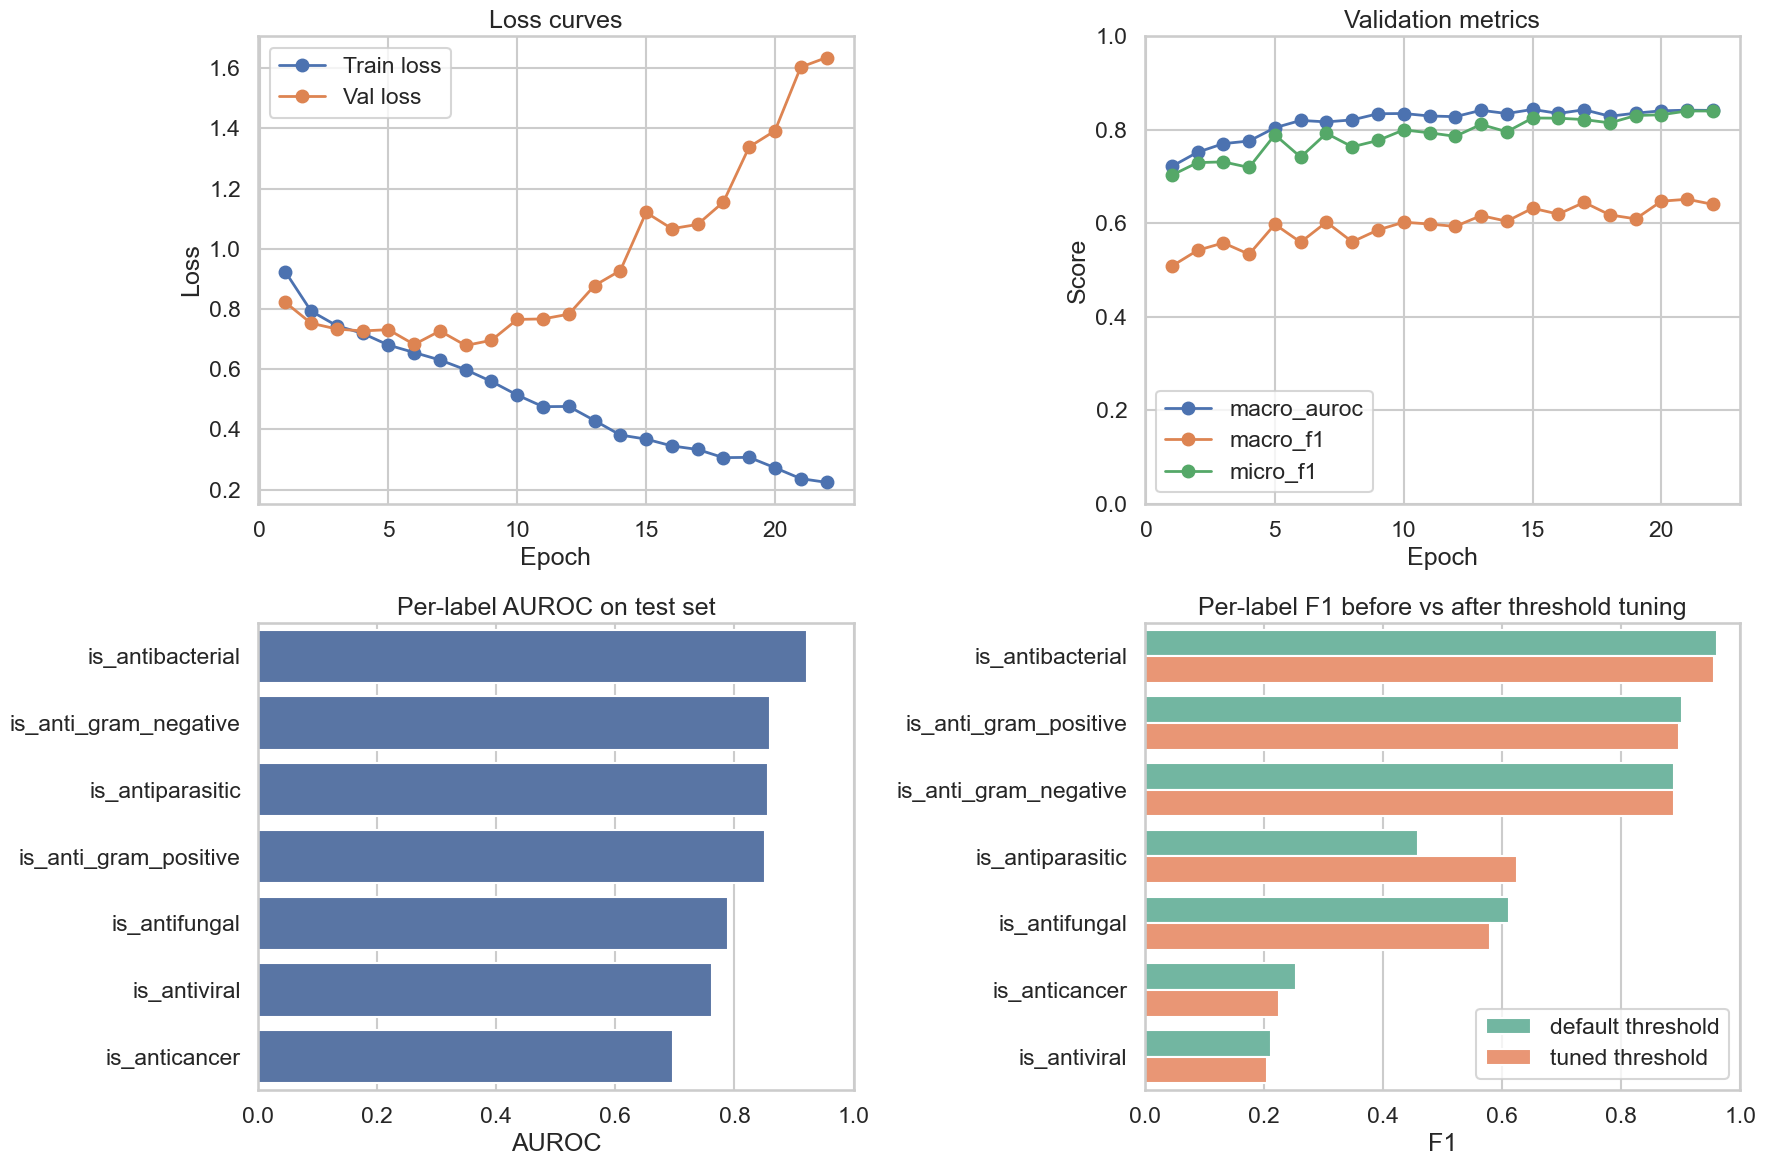

In [30]:
sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].plot(history_df["epoch"], history_df["train_loss"], marker="o", linewidth=2, label="Train loss")
axes[0, 0].plot(history_df["epoch"], history_df["val_loss"], marker="o", linewidth=2, label="Val loss")
axes[0, 0].set_title("Loss curves")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

metric_cols = [c for c in ["macro_auroc", "macro_f1", "micro_f1"] if c in history_df.columns]
for col in metric_cols:
    axes[0, 1].plot(history_df["epoch"], history_df[col], marker="o", linewidth=2, label=col)
axes[0, 1].set_title("Validation metrics")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Score")
axes[0, 1].set_ylim(0.0, 1.0)
axes[0, 1].legend()

auroc_plot_df = test_metrics_df[["label", "auroc"]].sort_values("auroc", ascending=False)
sns.barplot(data=auroc_plot_df, x="auroc", y="label", color="#4C72B0", ax=axes[1, 0])
axes[1, 0].set_title("Per-label AUROC on test set")
axes[1, 0].set_xlabel("AUROC")
axes[1, 0].set_ylabel("")
axes[1, 0].set_xlim(0.0, 1.0)

f1_compare_df = pd.concat([
    test_metrics_df[["label", "f1"]].assign(setting="default threshold"),
    test_metrics_tuned_df[["label", "f1"]].assign(setting="tuned threshold"),
], ignore_index=True)
label_order = (
    f1_compare_df[f1_compare_df["setting"] == "tuned threshold"]
    .sort_values("f1", ascending=False)["label"]
)
sns.barplot(
    data=f1_compare_df,
    x="f1",
    y="label",
    hue="setting",
    order=label_order,
    palette="Set2",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Per-label F1 before vs after threshold tuning")
axes[1, 1].set_xlabel("F1")
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlim(0.0, 1.0)
axes[1, 1].legend(title="")

plt.tight_layout()
plt.show()

### Plot review and baseline interpretation

The figure should be read as a compact summary of both **classifier quality** and **screening usability**.

**Training curves**
- If train and validation loss move together and plateau smoothly, the baseline is stable enough for downstream use.
- The goal here is not maximal leaderboard performance. The goal is a dependable evaluator with no obvious collapse or overfitting.

**Per-label AUROC panel**
- The easiest labels are the common AMP labels, especially antibacterial and Gram activity.
- The harder tail labels pull down the macro average and explain why macro metrics remain well below micro F1.

**F1 before vs after threshold tuning**
- The tuned-threshold bars show that much of the remaining gap is a calibration problem, not only a representation problem.
- Threshold tuning helps most where prevalence is low and the default `0.5` cut is too rigid.

**What this means for the project**
- As a baseline, the classifier is good enough to compare generation settings, report adherence trends, and rerank candidates.
- It is not yet strong enough to claim biological correctness of the generated peptides on its own.


## 13. Future work
This baseline is already useful for screening, but it should not be treated as a final biological validator.

High-value next steps:
1. Replace the random split with a **homology-aware split**.
2. Calibrate probabilities with temperature scaling, isotonic regression, or Platt scaling.
3. Add external toxicity and hemolysis predictors to turn adherence into a safer multi-objective screen.
4. Compare against stronger sequence encoders such as CNN or protein-language-model embeddings.
5. Use the classifier inside reranking or latent-space optimization loops instead of only post-hoc evaluation.
